# FGSM Adversarial Attacks

## Fast Gradient Sign Method - Implementazione e Valutazione

Questo notebook implementa attacchi FGSM da zero e valuta l'accuratezza del modello ResNet18 addestrato

## 1. Setup e Import

In [8]:
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5


model = models.resnet18(pretrained=True)
model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
model = model.to(device)

model_path = ROOT / "models" / "best_resnet18.pt"
model.load_state_dict(torch.load(model_path))
model.eval()


NORMALIZE = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

dataset_path = ROOT / "data" / "fruits-classification-stratified"

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRANSFORMS)
val_dataset = ImageFolder(root=dataset_path / 'valid', transform=TRANSFORMS)
test_dataset = ImageFolder(root=dataset_path / 'test', transform=TRANSFORMS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

print(f"\nSetup e import completati")



Setup e import completati


/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


## 2. Implementazione FGSM (da zero)

FGSM (Fast Gradient Sign Method) è il metodo più semplice per creare esempi adversarial:

1. Calcola il gradiente della loss rispetto all'immagine
2. Prende il segno del gradiente (direzione di massimo aumento dell'errore)
3. Moltiplica per epsilon e aggiunge all'immagine

In [9]:
def fgsm_attack(model, images, labels, epsilon, loss_fn):
    """
    Esegue un attacco FGSM su un batch di immagini
    
    Args:
        model: il modello target da ingannare
        images: batch di immagini 
        labels: label vere per il batch 
        epsilon: grandezza della perturbazione (0.01 - 0.5)
        loss_fn: funzione di loss (CrossEntropyLoss)
    
    Returns:
        adv_images: immagini perturbate 
        perturbation: il rumore aggiunto 
    """
    
    # abilita il calcolo dei gradienti rispetto alle immagini
    images.requires_grad = True
    
    outputs = model(NORMALIZE(images))
    loss = loss_fn(outputs, labels)
    
    # pulisce i gradienti precedenti (utile se si chiama la funzione piu volte)
    model.zero_grad()
    
    loss.backward()
    
    # estrae il segno dei gradienti (solo direzione, non ampiezza)
    gradient_sign = images.grad.sign()
    
    perturbation = epsilon * gradient_sign
    adv_images = images + perturbation
    
    # Clip i valori nel range [0, 1] (valori pixel validi)
    adv_images = torch.clamp(adv_images, 0, 1)
    
    # per adesso non mi servono i gradienti, quindi scollego le immagini perturbate (libero memoria)
    adv_images = adv_images.detach()
    images.requires_grad = False

    perturbation = adv_images - images
    
    return adv_images, perturbation.detach()


print("Funzione FGSM implementata")

Funzione FGSM implementata


## 3. Test FGSM con Epsilon diversi

Testare l'attacco FGSM su diversi valori di epsilon per capire quando il modello inizia a sbagliare.

Metriche:
- **Accuracy**: % di immagini classificate correttamente dal modello (senza attacco)
- **Attack Success Rate (ASR)**: % di immagini dove l'attacco ha ingannato il modello
- **Time**: tempo totale per applicare l'attacco al test set

In [10]:
epsilon_values = [0.0005, 0.001, 0.003, 0.005, 0.01]
epsilon_to_visualize = [0.0005, 0.003, 0.01]

loss_fn = nn.CrossEntropyLoss()
fgsm_results = {}

examples_store = {eps: {'success': [], 'failure': []} for eps in epsilon_to_visualize}

for epsilon in epsilon_values:
    print(f"\nTest epsilon = {epsilon}")

    correct_original = 0 
    correct_adv = 0  
    attack_success_count = 0
    total_samples = 0

    start_time = time.time()

    model.eval()

    for images, labels in tqdm(test_loader, desc=f"epsilon={epsilon}"):
        images = images.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            outputs_original = model(NORMALIZE(images))
            preds_original = torch.argmax(outputs_original, dim=1)
            correct_original += (preds_original == labels).sum().item()

        # ATTACCO FGSM
        adv_images, perturbation = fgsm_attack(
            model,
            images.clone().requires_grad_(True),
            labels,
            epsilon,
            loss_fn,
        )

        with torch.no_grad():
            outputs_adv = model(NORMALIZE(adv_images))  
            preds_adv = torch.argmax(outputs_adv, dim=1)
            correct_adv += (preds_adv == labels).sum().item()

        success = (preds_original == labels) & (preds_adv != labels)
        attack_success_count += success.sum().item()

        total_samples += labels.size(0)

        if epsilon in epsilon_to_visualize:
           for i in range(images.size(0)):
            pred_orig = preds_original[i].item()
            pred_adv = preds_adv[i].item()
            true_label = labels[i].item()

            attack_success = pred_orig == true_label and pred_adv != true_label
            attack_failure = pred_orig == true_label and pred_adv == true_label

            example = {
                'image': images[i:i+1].detach().cpu().clone(),
                'adv_image': adv_images[i:i+1].detach().cpu().clone(),
                'perturbation': perturbation[i:i+1].detach().cpu().clone(),
                'pred_original': pred_orig,
                'pred_adv': pred_adv,
                'true_label': true_label,
            }

            if attack_success: examples_store[epsilon]['success'].append(example)

            elif attack_failure: examples_store[epsilon]['failure'].append(example) 

    # metriche    
    accuracy = correct_original / total_samples
    accuracy_adv = correct_adv / total_samples
    accuracy_drop = accuracy - accuracy_adv
    asr = attack_success_count / correct_original  
    elapsed_time = time.time() - start_time

    fgsm_results[epsilon] = {
        'accuracy': accuracy,
        'accuracy_adv': accuracy_adv,
        'accuracy_drop': accuracy_drop,
        'asr': asr,
        'time': elapsed_time,
    }

    print(f"  Accuracy (clean): {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Accuracy (adversarial): {accuracy_adv:.4f} ({accuracy_adv*100:.2f}%)")
    print(f"  Accuracy Drop: {accuracy_drop:.4f} ({accuracy_drop*100:.2f}%)")
    print(f"  Attack Success Rate: {asr:.4f} ({asr*100:.2f}%)")
    print(f"  Tempo: {elapsed_time:.2f}s")

print("\nTest completato per tutti gli epsilon")


Test epsilon = 0.0005


epsilon=0.0005:   0%|          | 0/32 [00:00<?, ?it/s]

epsilon=0.0005: 100%|██████████| 32/32 [00:02<00:00, 14.89it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.8096 (80.96%)
  Accuracy Drop: 0.1022 (10.22%)
  Attack Success Rate: 0.1121 (11.21%)
  Tempo: 2.15s

Test epsilon = 0.001


epsilon=0.001: 100%|██████████| 32/32 [00:00<00:00, 33.95it/s]


...

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.3597 (35.97%)
  Accuracy Drop: 0.5521 (55.21%)
  Attack Success Rate: 0.6055 (60.55%)
  Tempo: 2.09s

Test epsilon = 0.005


epsilon=0.005: 100%|██████████| 32/32 [00:00<00:00, 34.29it/s]


  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.2395 (23.95%)
  Accuracy Drop: 0.6723 (67.23%)
  Attack Success Rate: 0.7374 (73.74%)
  Tempo: 0.93s

Test epsilon = 0.01


epsilon=0.01: 100%|██████████| 32/32 [00:01<00:00, 18.11it/s]

  Accuracy (clean): 0.9118 (91.18%)
  Accuracy (adversarial): 0.1443 (14.43%)
  Accuracy Drop: 0.7675 (76.75%)
  Attack Success Rate: 0.8418 (84.18%)
  Tempo: 1.77s

Test completato per tutti gli epsilon


## 4. Plot delle immagini perturbate

Per ogni epsilon verranno mostrate:
- immagini originali
- perturbazioni (rumore aggiunto)
- immagini perturbate (originale + rumore)

Questo aiuta a capire quanto l'attacco sia "visibile" all'occhio umano e come confonde il modello.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00050002337..0.00050002337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00050002337..0.00050002337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00050002337..0.00050002337].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00050002337..0.00050002337].



Epsilon = 0.0005


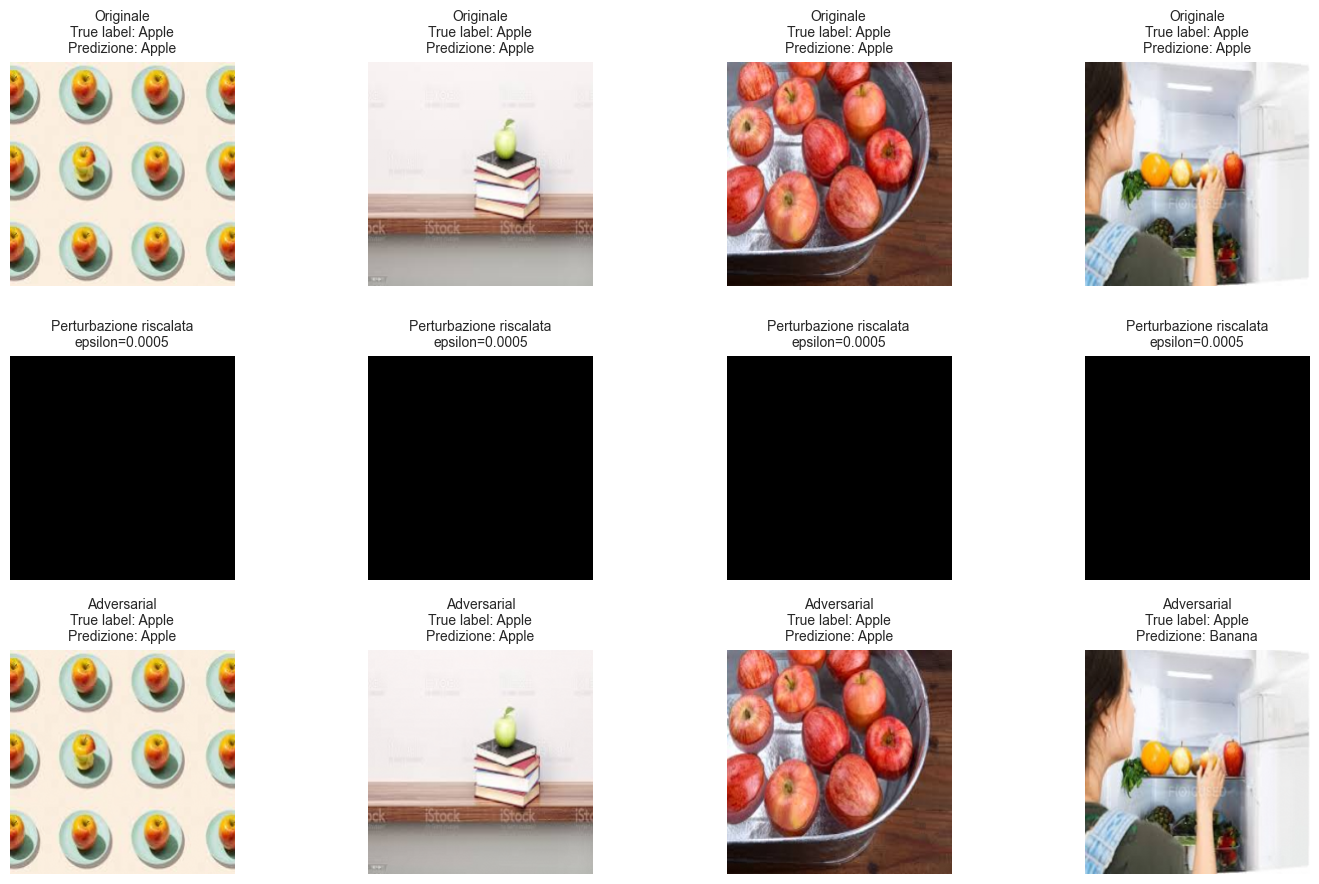

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003000021..0.003000021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003000021..0.003000021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003000021..0.003000021].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.003000021..0.003000021].



Epsilon = 0.003


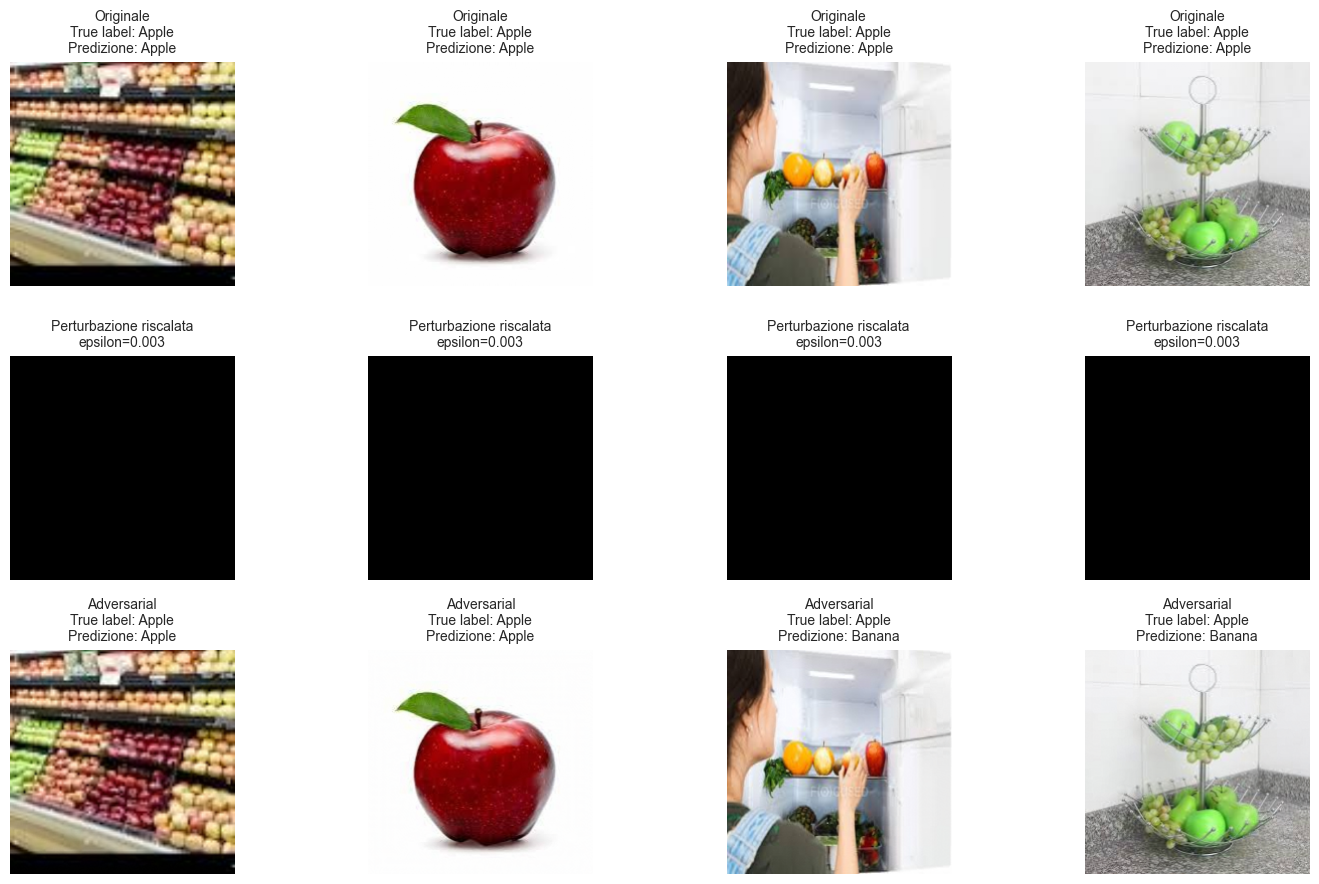

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010000005..0.01000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010000005..0.01000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010000005..0.01000002].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.010000005..0.01000002].



Epsilon = 0.01


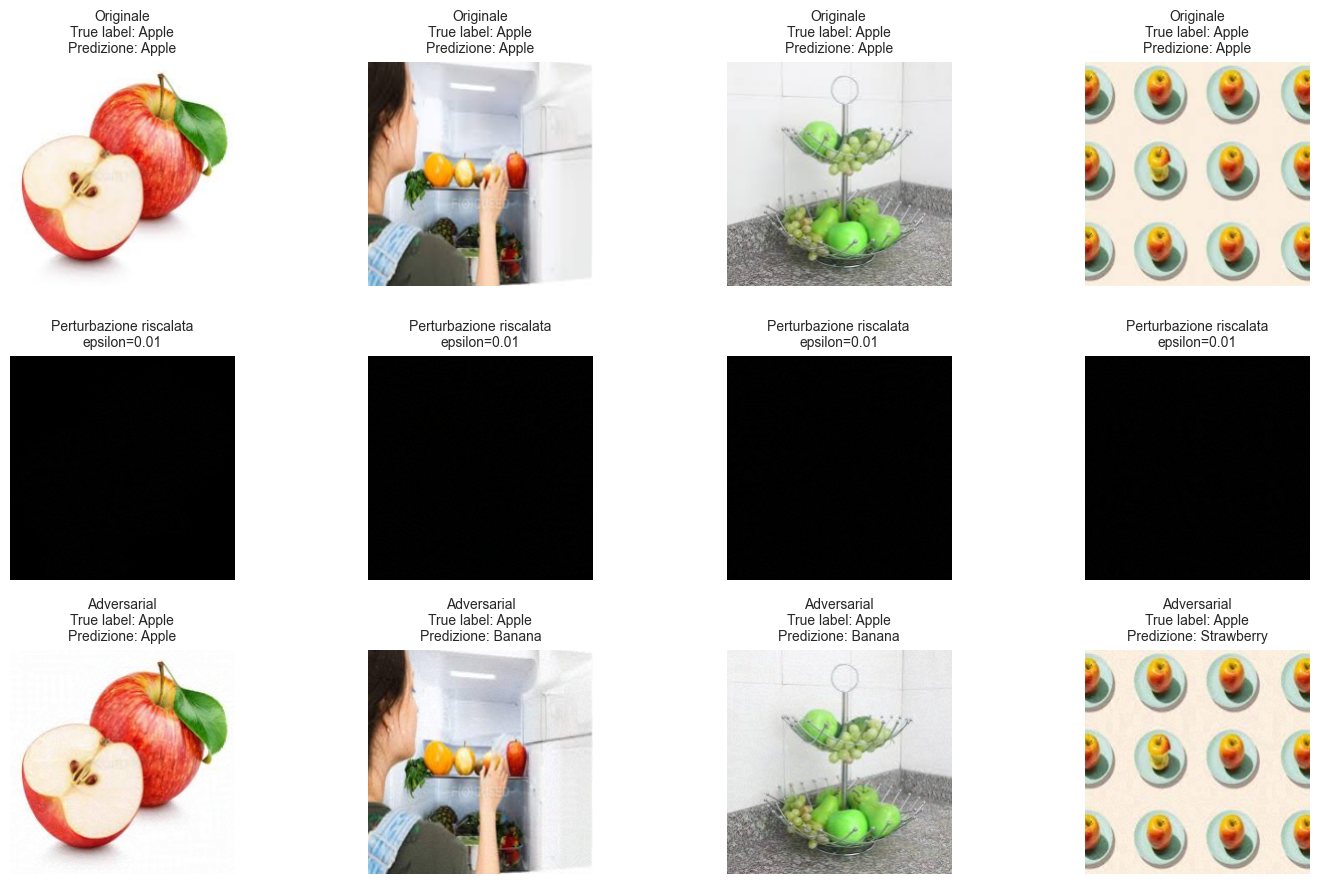

In [17]:
# eps=0.0005: 3 classificate bene + 1 classificata male
# eps=0.003: 2 classificate bene + 2 classificate male
# eps=0.01: 1 classificata bene + 3 classificate male
# scelti arbitrariamente

plot_config = {
    0.0005: {'correct': 3, 'wrong': 1},
    0.003: {'correct': 2, 'wrong': 2},
    0.01: {'correct': 1, 'wrong': 3},
}

for epsilon in epsilon_to_visualize:
    selected_examples = (
        examples_store[epsilon]['failure'][:plot_config[epsilon]['correct']] +
        examples_store[epsilon]['success'][:plot_config[epsilon]['wrong']]
    )

    fig, axes = plt.subplots(3, 4, figsize=(15, 9))

    for img_idx in range(4):
        example = selected_examples[img_idx]

        img_original = example['image'][0].numpy()
        img_original = np.transpose(img_original, (1, 2, 0))
        img_original = np.clip(img_original, 0, 1)

        perturbation = example['perturbation'][0].numpy()
        perturbation = np.transpose(perturbation, (1, 2, 0))

        img_adv = example['adv_image'][0].numpy()
        img_adv = np.transpose(img_adv, (1, 2, 0))
        img_adv = np.clip(img_adv, 0, 1)

        true_label = example['true_label']
        pred_original = example['pred_original']
        pred_adv = example['pred_adv']

        # immagini originali
        ax = axes[0, img_idx]
        ax.imshow(img_original)
        ax.set_title(f"Originale\nTrue label: {class_names[true_label]}\nPredizione: {class_names[pred_original]}", fontsize=10)
        ax.axis('off')

        # perturbazioni
        ax = axes[1, img_idx]
        ax.imshow(perturbation)
        ax.set_title(f"Perturbazione riscalata\nepsilon={epsilon}", fontsize=10)
        ax.axis('off')

        # immagini adversarial
        ax = axes[2, img_idx]
        ax.imshow(img_adv)
        ax.set_title(f"Adversarial\nTrue label: {class_names[true_label]}\nPredizione: {class_names[pred_adv]}", fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(results_path / f"fgsm_attack_{epsilon}.png", dpi=120, bbox_inches='tight')
    print(f"\nEpsilon = {epsilon}")
    plt.show()

## 5. Plot delle Metriche 

Generazioe di grafici riguardanti le metriche:
- Accuracy su immagini originali vs immagini perturbate
- Calo di accuracy (accuracy drop)
- Attack Success Rate (ASR)
- Tempo per applicare l'attacco al test set

/tmp/ipykernel_2441809/1275653133.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
/tmp/ipykernel_2441809/1275653133.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
/tmp/ipykernel_2441809/1275653133.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)


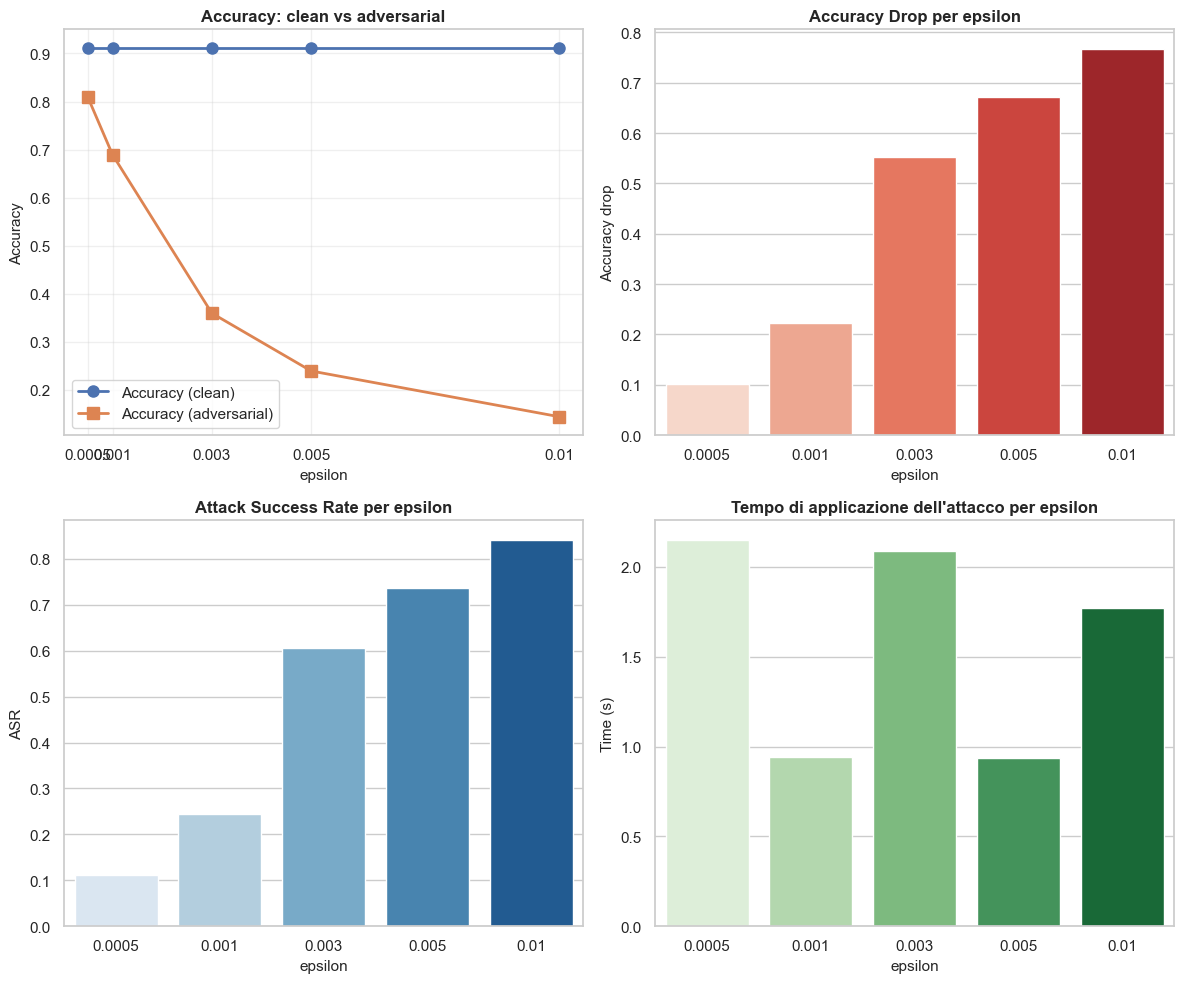

In [12]:
eps = epsilon_values
acc = [fgsm_results[e]['accuracy'] for e in eps]
acc_adv = [fgsm_results[e]['accuracy_adv'] for e in eps]
acc_drop = [fgsm_results[e]['accuracy_drop'] for e in eps]
asr = [fgsm_results[e]['asr'] for e in eps]
times = [fgsm_results[e]['time'] for e in eps]

eps_labels = [str(e) for e in eps]

sns.set(style='whitegrid')

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# accuracy: clean vs adversarial
ax = axes[0, 0]
ax.plot(eps, acc, marker='o', label='Accuracy (clean)', linewidth=2, markersize=8)
ax.plot(eps, acc_adv, marker='s', label='Accuracy (adversarial)', linewidth=2, markersize=8)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_xticks(eps)
ax.set_xticklabels(eps_labels)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy: clean vs adversarial', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# accuracy drop
ax = axes[0, 1]
sns.barplot(x=eps_labels, y=acc_drop, palette='Reds', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Accuracy drop', fontsize=11)
ax.set_title('Accuracy Drop per epsilon', fontsize=12, fontweight='bold')

# Attack Success Rate (ASR)
ax = axes[1, 0]
sns.barplot(x=eps_labels, y=asr, palette='Blues', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('ASR', fontsize=11)
ax.set_title('Attack Success Rate per epsilon', fontsize=12, fontweight='bold')

# tempo
ax = axes[1, 1]
sns.barplot(x=eps_labels, y=times, palette='Greens', ax=ax)
ax.set_xlabel('epsilon', fontsize=11)
ax.set_ylabel('Time (s)', fontsize=11)
ax.set_title("Tempo di applicazione dell'attacco per epsilon", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(results_path / 'FGSM_metrics_summary.png', dpi=120, bbox_inches='tight')
plt.show()

# tabella riassuntiva
summary_df = pd.DataFrame({
    'epsilon': eps,
    'accuracy': acc,
    'accuracy_adv': acc_adv,
    'accuracy_drop': acc_drop,
    'asr': asr,
    'time_s': times,
})
summary_df.to_csv(results_path / 'FGSM_metrics_summary.csv', index=False)

## 6. Adversarial Training

Addestramwnto di un nuovo modello con dati misti: 50% immagini originali + 50% immagini perturbate (FGSM con epsilon=0.1)

In [13]:
epsilon_adv_training = [0.0005, 0.003, 0.01]

model_path = ROOT / "models" / "best_resnet18.pt"

adv_loss_fn = nn.CrossEntropyLoss()

num_epochs = 50
patience = 20

adv_train_histories = {}
best_val_losses = {}
model_save_paths = {}

for epsilon in epsilon_adv_training:
    print(f"\nAdversarial training FGSM con epsilon = {epsilon}")

    # ogni training parte dallo stesso modello originale
    fgsm_model = models.resnet18(pretrained=True)
    fgsm_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
    fgsm_model = fgsm_model.to(device)
    fgsm_model.load_state_dict(torch.load(model_path))

    # nuovo optimizer per ogni modello
    adv_optimizer = torch.optim.Adam(fgsm_model.parameters(), lr=0.0001)

    # azzera early stopping e history
    best_val_loss = float('inf')
    patience_counter = 0

    adv_train_history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    model_save_path = (ROOT / "models" / f"best_fgsm_{epsilon}.pt")

    for epoch in range(num_epochs):
        fgsm_model.train()

        epoch_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in tqdm(train_loader, desc=f"epsilon={epsilon} - Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            labels = labels.to(device)

            batch_size_half = images.size(0) // 2

            clean_images = images[:batch_size_half]

            adv_images, perturbation = fgsm_attack(
                fgsm_model,
                images[batch_size_half:],
                labels[batch_size_half:],
                epsilon,
                adv_loss_fn
            )

            mixed_images = torch.cat([clean_images, adv_images], dim=0)
            mixed_labels = labels

            adv_optimizer.zero_grad()

            outputs = fgsm_model(NORMALIZE(mixed_images))
            loss = adv_loss_fn(outputs, mixed_labels)

            loss.backward()
            adv_optimizer.step()

            epoch_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct_train += (preds == mixed_labels).sum().item()
            total_train += mixed_labels.size(0)

        train_loss = epoch_loss / len(train_loader)
        train_acc = correct_train / total_train

        # validazione su immagini pulite
        fgsm_model.eval()

        val_loss = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = fgsm_model(NORMALIZE(images))
                loss = adv_loss_fn(outputs, labels)

                val_loss += loss.item()

                preds = torch.argmax(outputs, dim=1)
                correct_val += (preds == labels).sum().item()
                total_val += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_acc = correct_val / total_val

        adv_train_history['train_loss'].append(train_loss)
        adv_train_history['train_acc'].append(train_acc)
        adv_train_history['val_loss'].append(val_loss)
        adv_train_history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f}, Val Loss={val_loss:.4f}, Val Acc={val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            torch.save(fgsm_model.state_dict(),model_save_path)

        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break


    # conserva i risultati di questo training
    adv_train_histories[epsilon] = adv_train_history
    best_val_losses[epsilon] = best_val_loss
    model_save_paths[epsilon] = model_save_path

    print(f"Training completato per epsilon={epsilon}")
    print(f"Miglior validation loss: {best_val_loss:.4f}")

print("\nAdversarial training FGSM completato per tutti gli epsilon")

/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/imane/Thesis_AML/.venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Adversarial training FGSM con epsilon = 0.0005


epsilon=0.0005 - Epoch 1/50:  65%|██████▌   | 163/250 [00:03<00:01, 56.73it/s]

epsilon=0.0005 - Epoch 1/50: 100%|██████████| 250/250 [00:04<00:00, 52.37it/s]


Epoch 1: Train Loss=0.2272, Train Acc=0.9178, Val Loss=0.2434, Val Acc=0.9248


...

Epoch 21: Train Loss=0.0478, Train Acc=0.9836, Val Loss=0.4079, Val Acc=0.8968


epsilon=0.01 - Epoch 22/50: 100%|██████████| 250/250 [00:04<00:00, 50.99it/s]


Epoch 22: Train Loss=0.0471, Train Acc=0.9838, Val Loss=0.3998, Val Acc=0.8858


epsilon=0.01 - Epoch 23/50: 100%|██████████| 250/250 [00:04<00:00, 51.26it/s]


Epoch 23: Train Loss=0.0478, Train Acc=0.9831, Val Loss=0.4262, Val Acc=0.8778
Early stopping at epoch 23
Training completato per epsilon=0.01
Miglior validation loss: 0.2660

Adversarial training FGSM completato per tutti gli epsilon


## 7. Confronto: Modello Originale vs Modello FGSM

Confronto del modello originale con il modello addestrato avversarialmente.

Metriche:
- accuracy clean
- accuracy adversarial
- accuracy drop
- ASR 


Confronto FGSM con epsilon test = 0.0005


Confronto FGSM epsilon=0.0005: 100%|██████████| 32/32 [00:02<00:00, 13.56it/s]


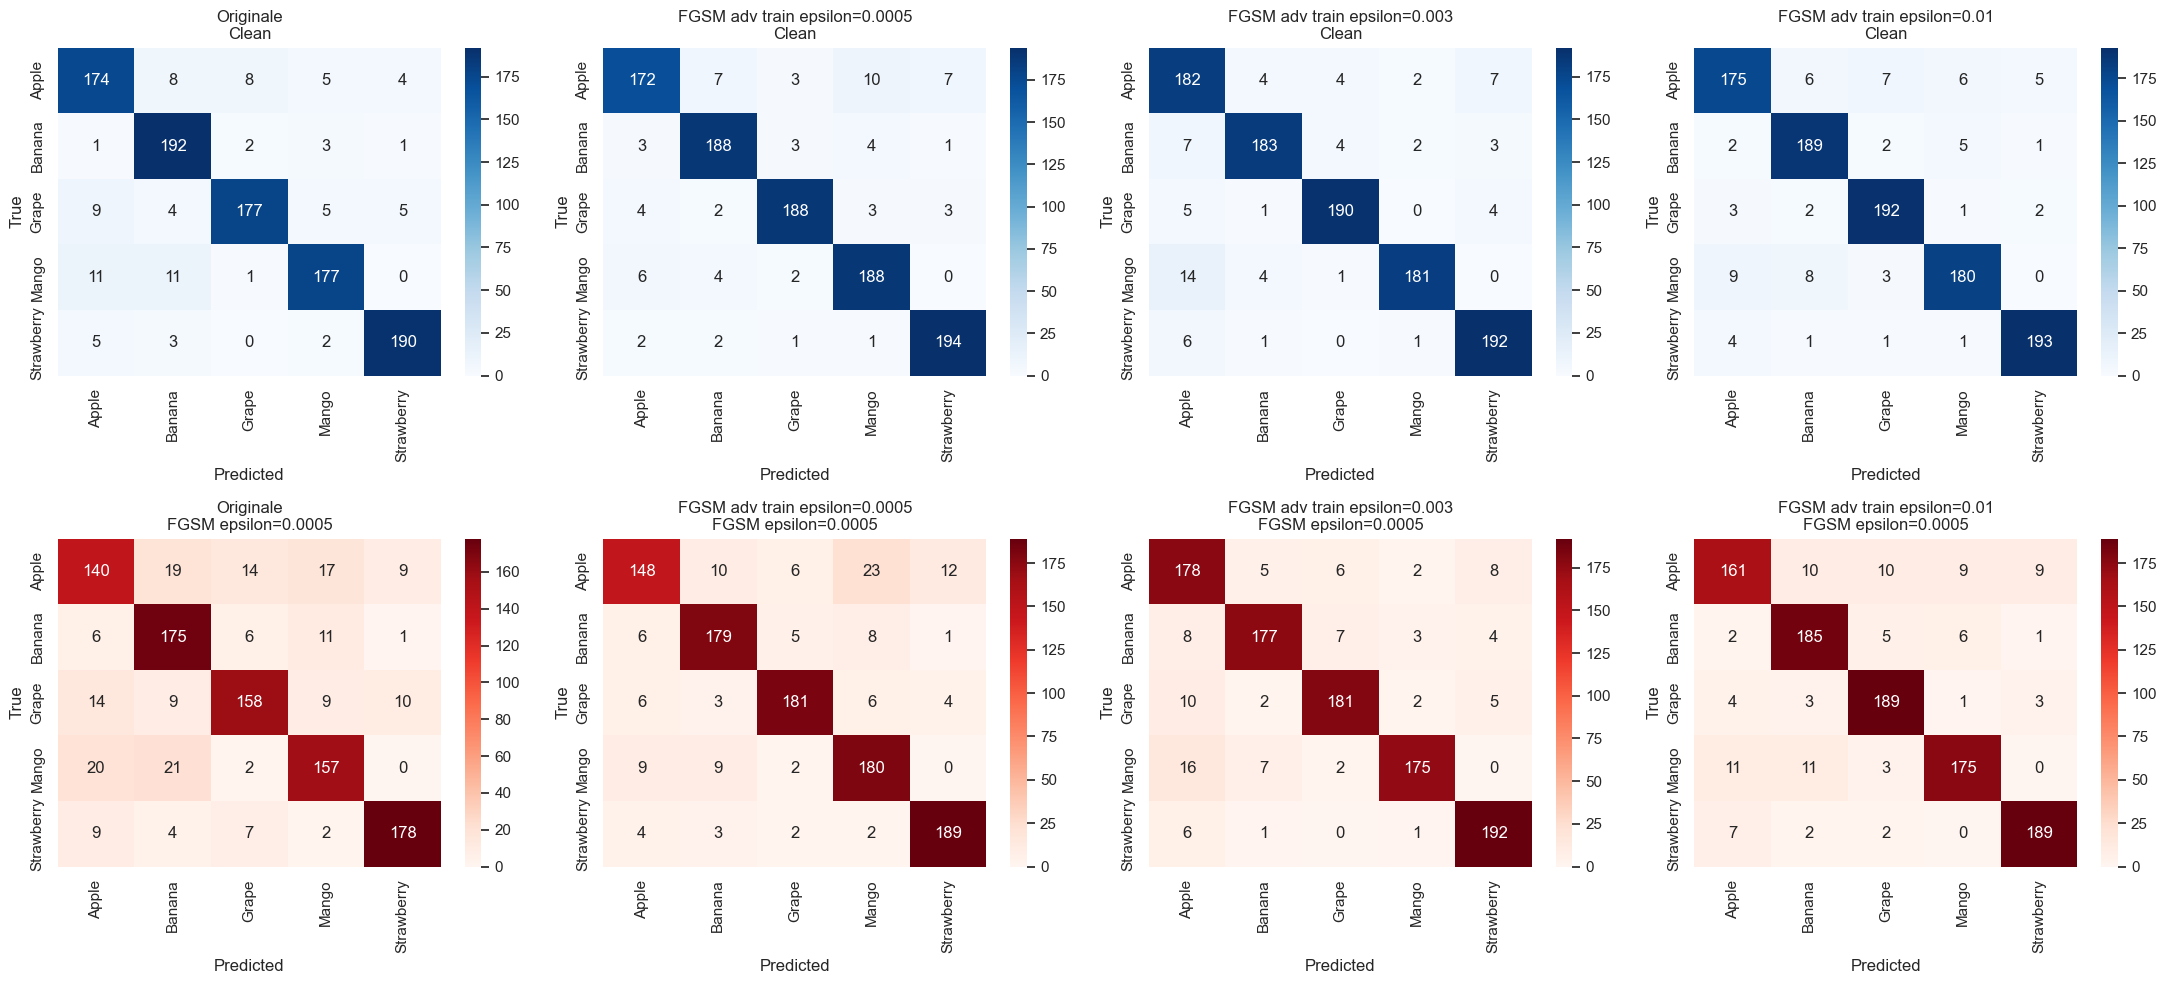


Confronto FGSM con epsilon test = 0.001


Confronto FGSM epsilon=0.001: 100%|██████████| 32/32 [00:02<00:00, 13.50it/s]


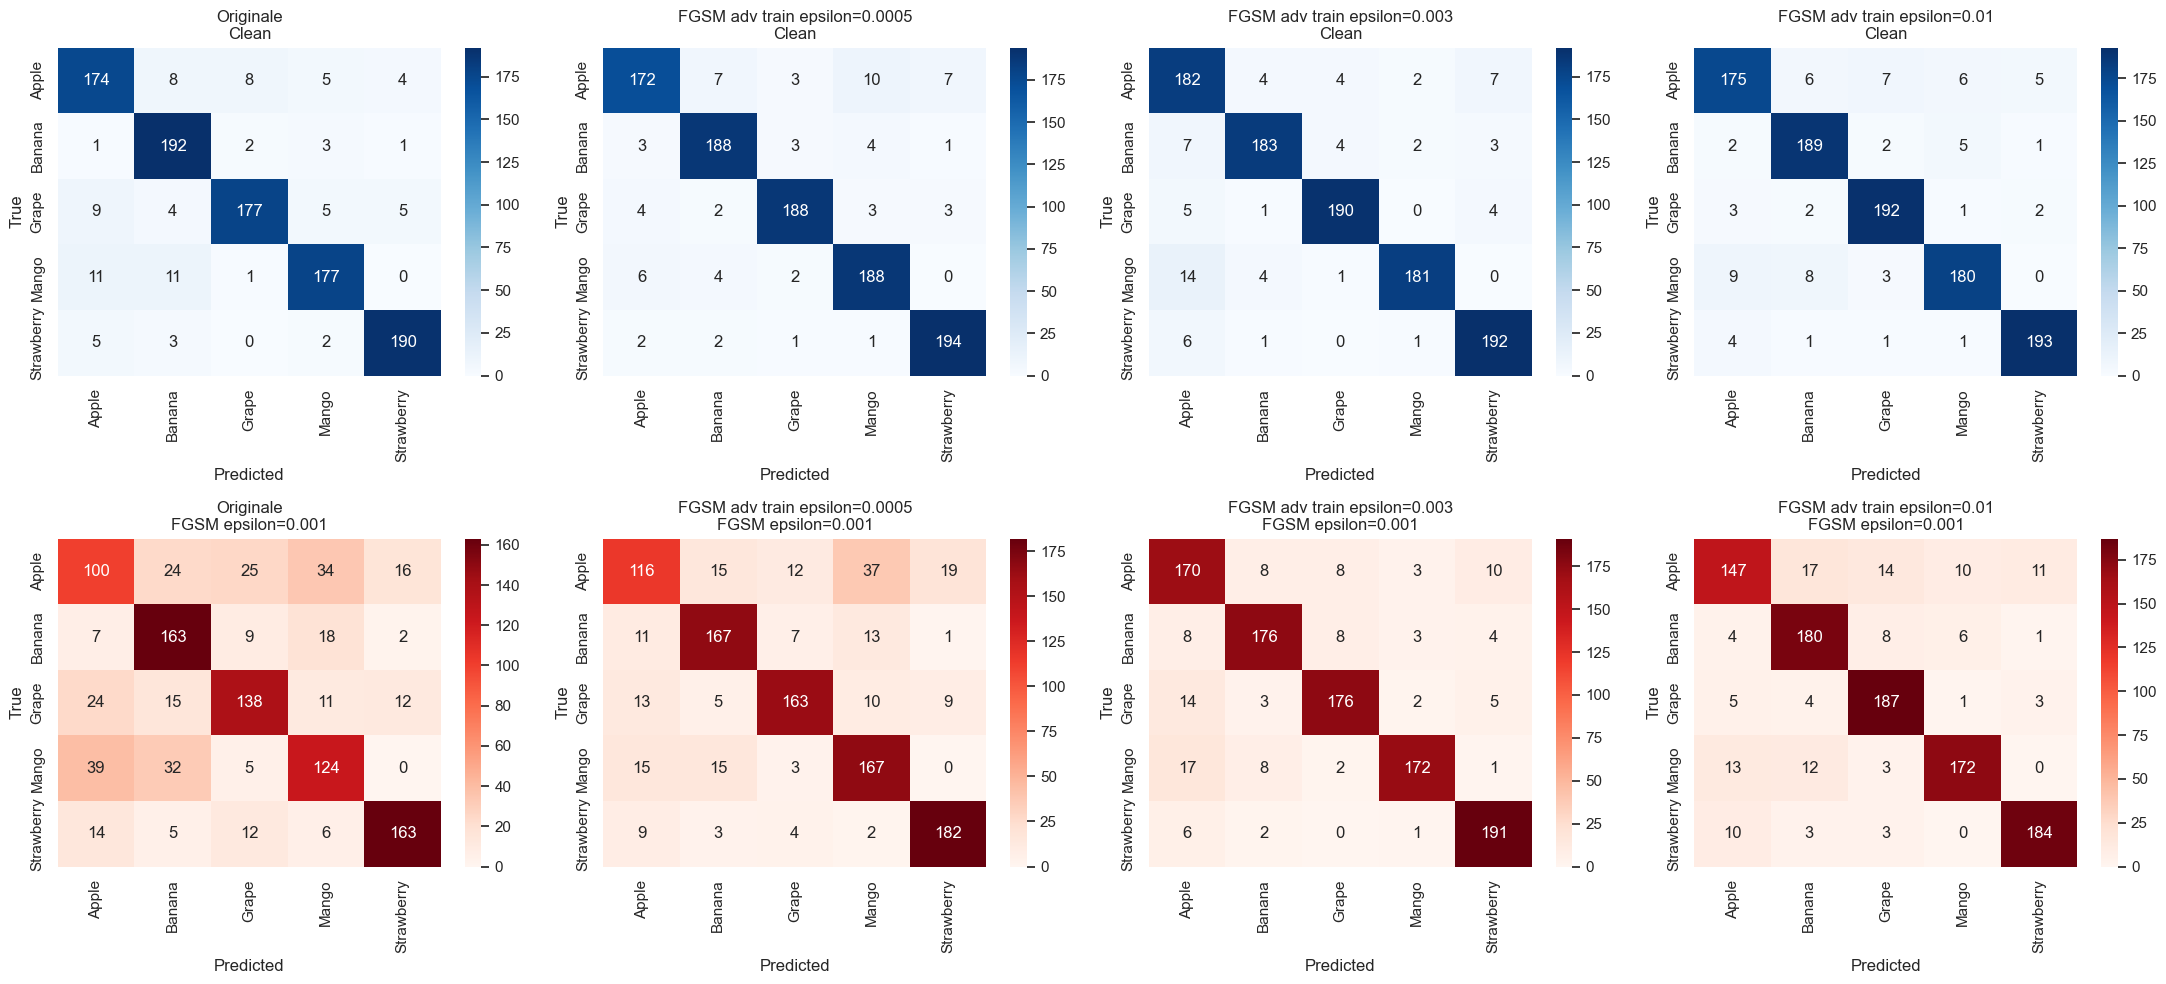


Confronto FGSM con epsilon test = 0.003


Confronto FGSM epsilon=0.003: 100%|██████████| 32/32 [00:02<00:00, 13.44it/s]


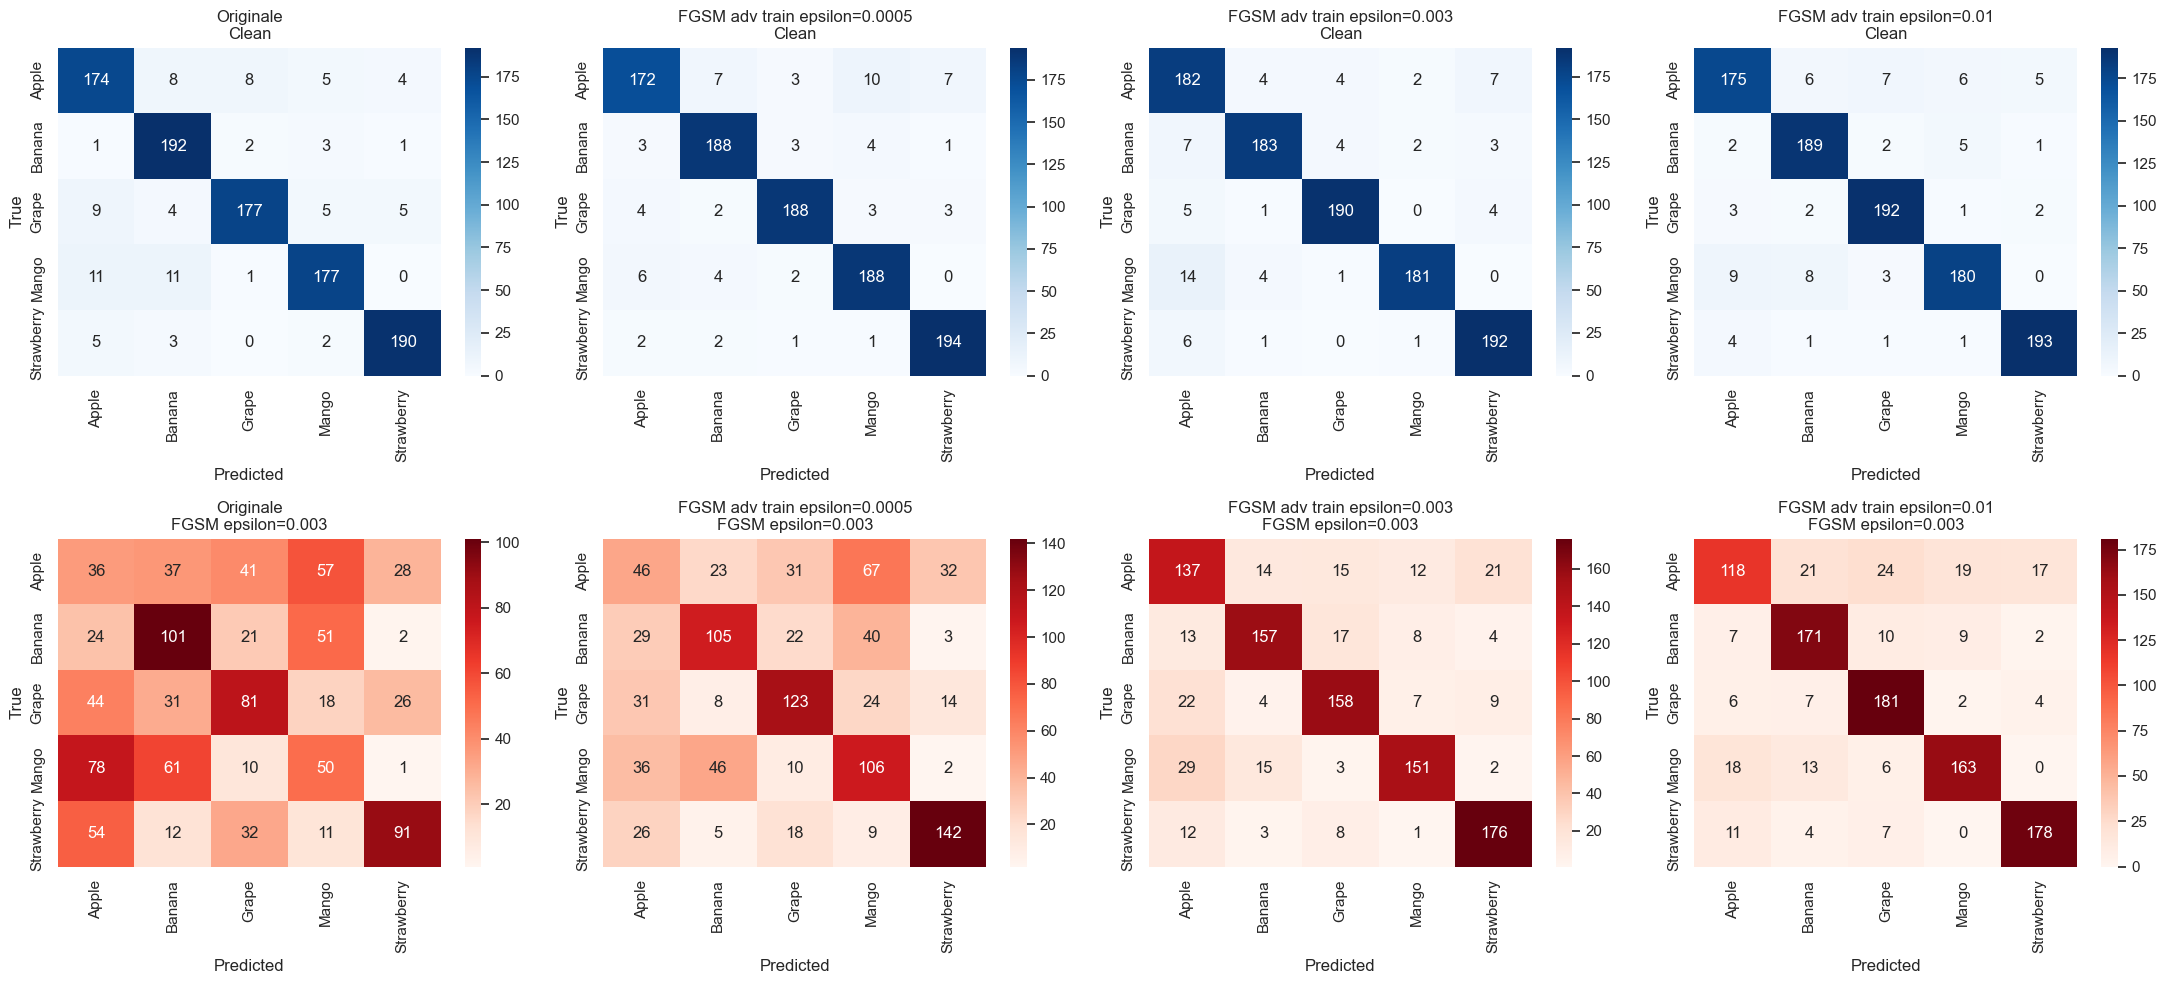


Confronto FGSM con epsilon test = 0.005


Confronto FGSM epsilon=0.005: 100%|██████████| 32/32 [00:02<00:00, 13.37it/s]


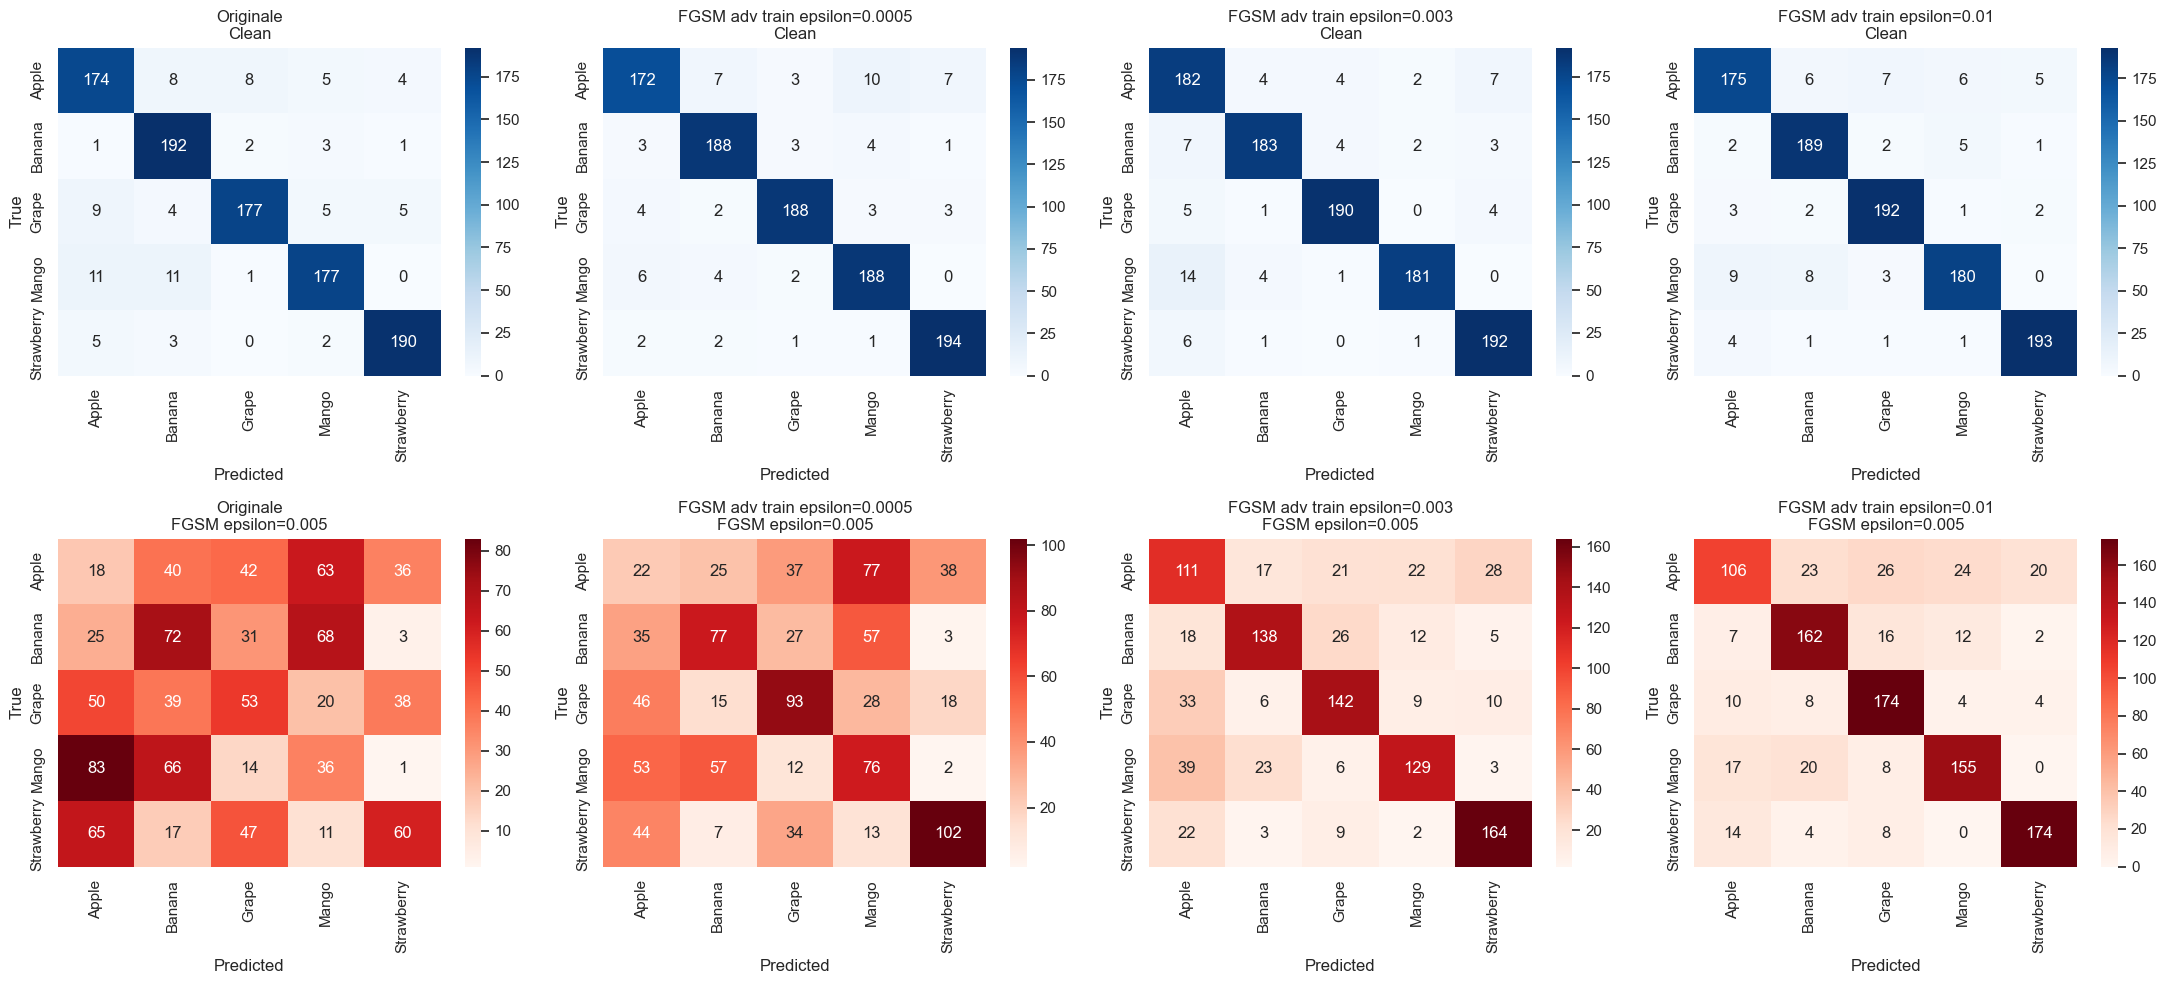


Confronto FGSM con epsilon test = 0.01


Confronto FGSM epsilon=0.01: 100%|██████████| 32/32 [00:02<00:00, 13.39it/s]


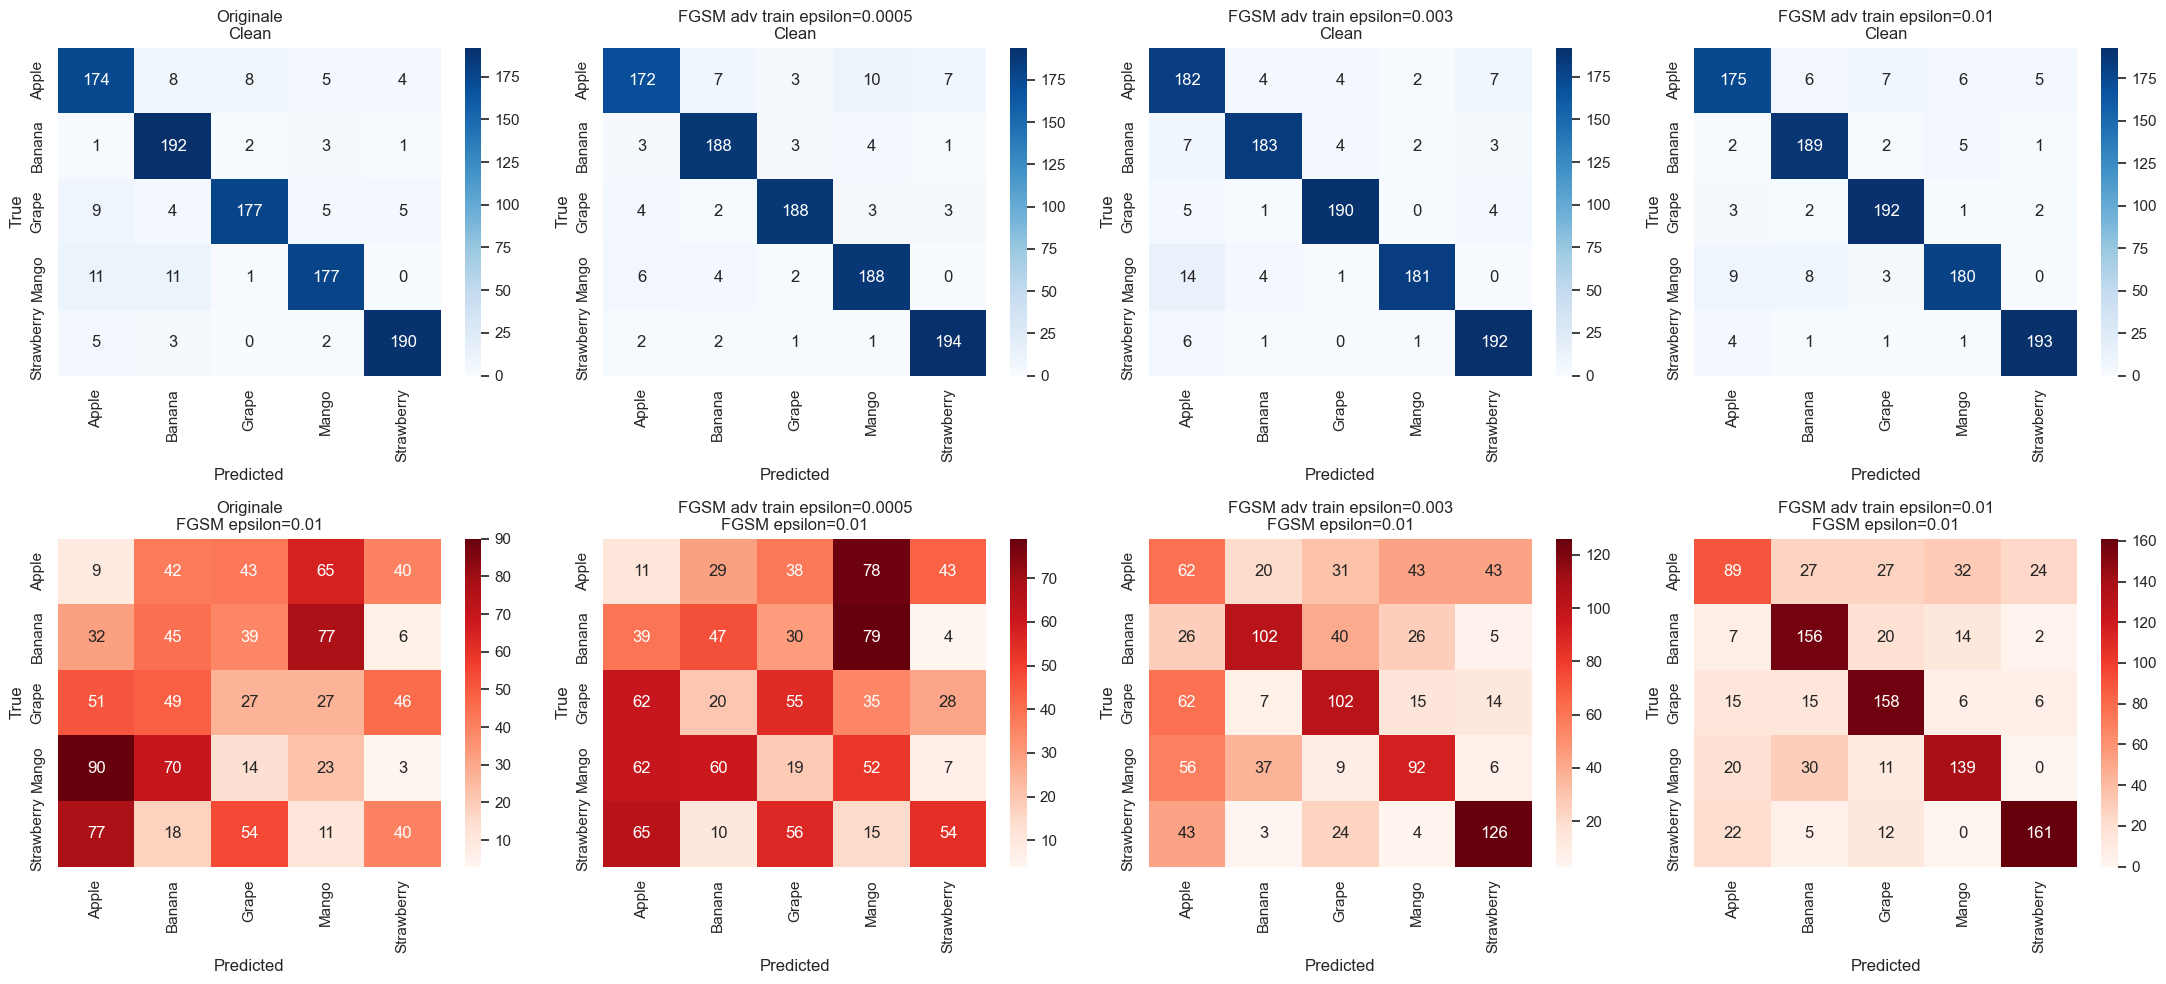

                    model  epsilon_training  epsilon_attack  accuracy_clean  accuracy_adversarial  accuracy_drop      asr
                Originale               NaN          0.0005        0.911824              0.809619       0.102204 0.112088
Adversarial Training FGSM            0.0005          0.0005        0.931864              0.878758       0.053106 0.056989
Adversarial Training FGSM            0.0030          0.0005        0.929860              0.904810       0.025050 0.026940
Adversarial Training FGSM            0.0100          0.0005        0.930862              0.900802       0.030060 0.032293
                Originale               NaN          0.0010        0.911824              0.689379       0.222445 0.243956
Adversarial Training FGSM            0.0005          0.0010        0.931864              0.796593       0.135271 0.145161
Adversarial Training FGSM            0.0030          0.0010        0.929860              0.886774       0.043086 0.046336
Adversarial Training FGS

In [14]:
epsilon_test_values = [0.0005, 0.001, 0.003, 0.005, 0.01]

# modelli da confrontare
comparison_models = {
    'Originale': {
        'model': model,
        'epsilon_training': None
    }
}

for epsilon_training in epsilon_adv_training:
    fgsm_model = models.resnet18(pretrained=True)
    fgsm_model.fc = nn.Linear(in_features=512, out_features=N_CLASSES)
    fgsm_model = fgsm_model.to(device)

    model_save_path = ROOT / "models" / f"best_fgsm_{epsilon_training}.pt"
    fgsm_model.load_state_dict(torch.load(model_save_path))
    fgsm_model.eval()

    comparison_models[f'FGSM adv train epsilon={epsilon_training}'] = {
        'model': fgsm_model,
        'epsilon_training': epsilon_training
    }

model.eval()

comparison_results = []

for epsilon_test in epsilon_test_values:
    print(f"\nConfronto FGSM con epsilon test = {epsilon_test}")

    # contatori e predizioni per ciascun modello
    comparison_stats = {}

    for model_name in comparison_models:
        comparison_stats[model_name] = {
            'correct_clean': 0,
            'correct_adv': 0,
            'attack_success': 0,
            'preds_clean': [],
            'preds_adv': []
        }

    total = 0
    all_labels = []

    for images, labels in tqdm(test_loader, desc=f"Confronto FGSM epsilon={epsilon_test}"):
        images = images.to(device)
        labels = labels.to(device)

        all_labels.extend(labels.cpu().numpy())
        total += labels.size(0)

        # valutazione modelli
        for model_name, model_info in comparison_models.items():
            current_model = model_info['model']

            # immagini pulite
            with torch.no_grad():
                outputs_clean = current_model(NORMALIZE(images))
                preds_clean = torch.argmax(outputs_clean, dim=1)

            # immagini adversarial generate contro il modello corrente
            adv_images, perturbation = fgsm_attack(
                current_model,
                images.clone().requires_grad_(True),
                labels,
                epsilon_test,
                loss_fn
            )

            with torch.no_grad():
                outputs_adv = current_model(NORMALIZE(adv_images))
                preds_adv = torch.argmax(outputs_adv, dim=1)

            comparison_stats[model_name]['correct_clean'] += (preds_clean == labels).sum().item()

            comparison_stats[model_name]['correct_adv'] += (preds_adv == labels).sum().item()

            comparison_stats[model_name]['attack_success'] += ((preds_clean == labels) & (preds_adv != labels)).sum().item()

            comparison_stats[model_name]['preds_clean'].extend(preds_clean.cpu().numpy())

            comparison_stats[model_name]['preds_adv'].extend(preds_adv.cpu().numpy())

    # metriche
    for model_name, model_info in comparison_models.items():
        stats = comparison_stats[model_name]

        accuracy_clean = stats['correct_clean'] / total
        accuracy_adv = stats['correct_adv'] / total
        accuracy_drop = accuracy_clean - accuracy_adv
        asr = stats['attack_success'] / stats['correct_clean']

        if model_info['epsilon_training'] is None:
            csv_model_name = 'Originale'
        else:
            csv_model_name = 'Adversarial Training FGSM'

        comparison_results.append({
            'model': csv_model_name,
            'epsilon_training': model_info['epsilon_training'],
            'epsilon_attack': epsilon_test,
            'accuracy_clean': accuracy_clean,
            'accuracy_adversarial': accuracy_adv,
            'accuracy_drop': accuracy_drop,
            'asr': asr
        })

    # plot per ogni epsilon di test
    fig, axes = plt.subplots(
        2,
        len(comparison_models),
        figsize=(22, 10)
    )

    for column, (model_name, model_info) in enumerate(
        comparison_models.items()
    ):
        stats = comparison_stats[model_name]

        cm_clean = confusion_matrix(
            all_labels,
            stats['preds_clean']
        )

        cm_adv = confusion_matrix(
            all_labels,
            stats['preds_adv']
        )

        sns.heatmap(
            cm_clean,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[0, column]
        )

        axes[0, column].set_title(f'{model_name}\nClean')
        axes[0, column].set_xlabel('Predicted')
        axes[0, column].set_ylabel('True')

        sns.heatmap(
            cm_adv,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=class_names,
            yticklabels=class_names,
            ax=axes[1, column]
        )

        axes[1, column].set_title(
            f'{model_name}\nFGSM epsilon={epsilon_test}'
        )
        axes[1, column].set_xlabel('Predicted')
        axes[1, column].set_ylabel('True')

    plt.tight_layout()

    plt.savefig(
        results_path / f"FGSM_comparison_epsilon_{epsilon_test}.png",
        dpi=120,
        bbox_inches='tight'
    )

    plt.show()

# tabella riassuntiva
comparison_df = pd.DataFrame(comparison_results)

print(comparison_df.to_string(index=False))

comparison_df.to_csv(
    results_path / "FGSM_original_vs_adv.csv",
    index=False
)